# CS4350/7350 - Big Data Analytics  
## Phase 2 Starter Notebook: Spark ML Pipeline (Jigsaw Toxic Comment Dataset)

### Purpose
This notebook uses the **Jigsaw Toxic Comment Classification Challenge** training data with **Apache Spark (PySpark) and Spark ML Pipelines**.

### Important
- You must use:
  - **Spark DataFrames**
  - **Spark MLlib**
  - **Spark ML Pipelines**
- Using only `pandas`, `scikit-learn`, or non-Spark ML code does **not** satisfy the project requirements.

### What you still must complete
You are expected to:
1. Download the Kaggle Jigsaw toxic comment data
2. Run the notebook using Spark
3. Review and improve comments where needed
4. Verify all required metrics
5. Add interpretation and discussion
6. Write the 3-4 page report


## Environment Setup

Recommended options:
1. **Databricks Community Edition**
2. **Local PySpark installation**

This notebook expects the Kaggle competition training file from:  
https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data

Download `train.csv.zip` from Kaggle and place it in this notebook directory, or extract it and place `train.csv` here. The code below will use `train.csv` directly or extract it from `train.csv.zip` if needed.


In [1]:
# If PySpark is missing, run this once in a notebook cell:
# %pip install pyspark


In [1]:
# Local Kaggle file names.
DATA_PATH = "data/train.csv"

# Databricks example after uploading the CSV:
# DATA_PATH = "/FileStore/tables/train.csv"


In [2]:
# Windows PySpark setup
import os
import sys
from pathlib import Path

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17.0.2"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

# Remove stale Spark settings that can break pip-installed PySpark
os.environ.pop("SPARK_HOME", None)
os.environ.pop("PYTHONPATH", None)
os.environ.pop("PYSPARK_SUBMIT_ARGS", None)

# Make sure Spark workers use this same .venv Python
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import pyspark

print("Python:", sys.executable)
print("PySpark version:", pyspark.__version__)
print("PySpark location:", pyspark.__file__)
print("JAVA_HOME:", os.environ["JAVA_HOME"])

jars_path = Path(pyspark.__file__).parent / "jars"
jars = list(jars_path.glob("*.jar"))

print("JAR path:", jars_path)
print("Number of Spark JARs:", len(jars))

Python: c:\Users\alex4\OneDrive\Desktop\Big_Data\.venv\Scripts\python.exe
PySpark version: 4.1.1
PySpark location: c:\Users\alex4\OneDrive\Desktop\Big_Data\.venv\Lib\site-packages\pyspark\__init__.py
JAVA_HOME: C:\Program Files\Java\jdk-17.0.2
JAR path: c:\Users\alex4\OneDrive\Desktop\Big_Data\.venv\Lib\site-packages\pyspark\jars
Number of Spark JARs: 286


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    RandomForestClassifier,
)

#start spark
spark = (
    SparkSession.builder
    .appName("CS4350_7350_Phase2_Toxic_Comments")
    .master("local[*]")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)

spark


## 1. Load the Dataset into a Spark DataFrame

The project requires the use of a **Spark DataFrame**, not a pandas DataFrame.

The Kaggle training file contains the text column `comment_text` plus six binary toxicity labels:
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

For this Spark ML starter workflow, we create one binary target named `label`: 1 if any toxicity column is positive, otherwise 0.


In [4]:
# Extract train.csv locally
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Download train.csv.zip from Kaggle and place it in this folder."
    )

# Load the Jigsaw toxic comment training data.
raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(DATA_PATH)
)

toxic_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Keep the text and create a single binary target for Spark binary classifiers.
df = (
    raw_df
    .select("id", "comment_text", *toxic_cols)
    .dropna(subset=["comment_text"])
    .withColumn(
        "label",
        (
            F.col("toxic").cast("int")
            + F.col("severe_toxic").cast("int")
            + F.col("obscene").cast("int")
            + F.col("threat").cast("int")
            + F.col("insult").cast("int")
            + F.col("identity_hate").cast("int")
            > 0
        ).cast("double")
    )
)
#df = df.sample(fraction=0.2, seed=42) # Sample 20% of the data for faster experimentation. REMOVE BEOFRE SUBMISSION!
print("Row count:", df.count())
print("Column count:", len(df.columns))
df.printSchema()
df.select("id", "comment_text", "label", *toxic_cols).show(5, truncate=80)


Row count: 159571
Column count: 9
root
 |-- id: string (nullable = true)
 |-- comment_text: string (nullable = true)
 |-- toxic: integer (nullable = true)
 |-- severe_toxic: integer (nullable = true)
 |-- obscene: integer (nullable = true)
 |-- threat: integer (nullable = true)
 |-- insult: integer (nullable = true)
 |-- identity_hate: integer (nullable = true)
 |-- label: double (nullable = true)

+----------------+--------------------------------------------------------------------------------+-----+-----+------------+-------+------+------+-------------+
|              id|                                                                    comment_text|label|toxic|severe_toxic|obscene|threat|insult|identity_hate|
+----------------+--------------------------------------------------------------------------------+-----+-----+------------+-------+------+------+-------------+
|0000997932d777bf|Explanation\nWhy the edits made under my username Hardcore Metallica Fan were...|  0.0|    0|    

## 2. Exploratory Data Analysis (EDA)

Minimum expectations:
- Show the schema
- Show summary statistics
- Show class distribution
- Check for missing values
- Review the label balance for the toxicity categories


In [5]:
# Summary statistics for binary label columns.
df.select("label", *toxic_cols).describe().show()

# Binary class distribution for the modeling label.
df.groupBy("label").count().orderBy("label").show()

# Individual toxicity label counts.
df.select([F.sum(F.col(c).cast("int")).alias(c) for c in toxic_cols]).show()

# Check for nulls.
null_counts = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns
])
null_counts.show()


+-------+-------------------+-------------------+--------------------+-----------------+--------------------+-------------------+-------------------+
|summary|              label|              toxic|        severe_toxic|          obscene|              threat|             insult|      identity_hate|
+-------+-------------------+-------------------+--------------------+-----------------+--------------------+-------------------+-------------------+
|  count|             159571|             159571|              159571|           159571|              159571|             159571|             159571|
|   mean|0.10167887648758234|0.09584448302009764|0.009995550569965721|0.052948217407925|0.002995531769557125|0.04936360616904074|0.00880485802558109|
| stddev| 0.3022264961563371| 0.2943787715999705| 0.09947714085748408|0.223930832915411| 0.05464958623142267| 0.2166267172768179|0.09342048594149767|
|    min|                0.0|                  0|                   0|                0|            

## 3. Feature Engineering and Label Preparation

We will:
1. Tokenize each comment
2. Remove common stop words
3. Convert tokens into hashed term-frequency vectors
4. Apply IDF weighting
5. Use the resulting vector as Spark ML features

The target column is already numeric and named `label`.


In [6]:
# Text feature pipeline.
tokenizer = Tokenizer(inputCol="comment_text", outputCol="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="tf_features", numFeatures=4096)
idf = IDF(inputCol="tf_features", outputCol="features")

base_pipeline = Pipeline(stages=[tokenizer, stopwords, hashing_tf, idf])
prepared_df = base_pipeline.fit(df).transform(df)

prepared_df.select("comment_text", "label", "features").show(5, truncate=80)


+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|                                                                    comment_text|label|                                                                        features|
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|Explanation\nWhy the edits made under my username Hardcore Metallica Fan were...|  0.0|(4096,[147,199,280,424,495,763,1463,1476,1520,1568,1924,2022,2144,2218,2254,2...|
|D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (...|  0.0|(4096,[23,618,918,995,1145,1418,1864,2011,2195,2536,3178,3420,3596,3666,4019]...|
|Hey man, I'm really not trying to edit war. It's just that this guy is consta...|  0.0|(4096,[16,316,355,840,1099,1253,1358,1710,1774,2155,2218,2493,

## 4. Train/Test Split

Use a fixed seed for reproducibility.


In [7]:
# Split into training and testing sets
train_df, test_df = prepared_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())


Training rows: 127502
Testing rows: 32069


## 5. Approved Spark Models

This binary toxic-comment target supports the following Spark-compatible classifiers:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient-Boosted Tree Classifier
- Linear Support Vector Classifier
- Naive Bayes

I (Alex) am doing decision tree and random forest.

All models use the same `features` vector created from the comment text.


In [8]:
# Binary classification models for the toxic comment dataset, doing my two models
models = {
    "Random Forest Classifier": RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100, seed=42),
    "Decision Tree Classifier": DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=42)
}

print("Training Random Forest and Decision Tree Spark classifiers on the Jigsaw toxic comment target.")


Training Random Forest and Decision Tree Spark classifiers on the Jigsaw toxic comment target.


## 6. Train and Evaluate Models

Required metrics:
- Accuracy
- Precision
- Recall
- F1-score

The comparison table below helps satisfy the model comparison requirement.


In [9]:
# Define evaluation metrics.
import pandas as pd #for results display
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy"),
    "f1": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1"),
    "weightedPrecision": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision"),
    "weightedRecall": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall"),
}

# Train, predict, and evaluate each model.
results = []
predictions_dict = {}

for model_name, estimator in models.items():
    model = estimator.fit(train_df)
    preds = model.transform(test_df)
    predictions_dict[model_name] = preds

    row = {
        "model": model_name,
        "accuracy": evaluators["accuracy"].evaluate(preds),
        "f1": evaluators["f1"].evaluate(preds),
        "precision": evaluators["weightedPrecision"].evaluate(preds),
        "recall": evaluators["weightedRecall"].evaluate(preds),
    }
    results.append(row)

# Display results sorted by accuracy.
# Display results sorted by accuracy without Spark DataFrame

results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
results_df


,model,accuracy,f1,precision,recall
1,Decision Tree Classifier,0.916025,0.895090,0.906447,0.916025
0,Random Forest Classifier,0.898594,0.850599,0.807471,0.898594


## 7. Confusion Matrices for At Least Two Models

The project requires a confusion matrix for at least two models.

Here are confusion matrix for Decision Tree and Random Forest

In [10]:
def show_confusion_matrix(preds, title):
    print(f"\nConfusion Matrix: {title}")
    (
        preds.groupBy("label", "prediction")
        .count()
        .orderBy("label", "prediction")
        .show()
    )

# Show confusion matrices for your two models.
show_confusion_matrix(predictions_dict["Decision Tree Classifier"], "Decision Tree Classifier")
show_confusion_matrix(predictions_dict["Random Forest Classifier"], "Random Forest Classifier")


Confusion Matrix: Decision Tree Classifier
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|28606|
|  0.0|       1.0|  211|
|  1.0|       0.0| 2482|
|  1.0|       1.0|  770|
+-----+----------+-----+


Confusion Matrix: Random Forest Classifier
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|28817|
|  1.0|       0.0| 3252|
+-----+----------+-----+



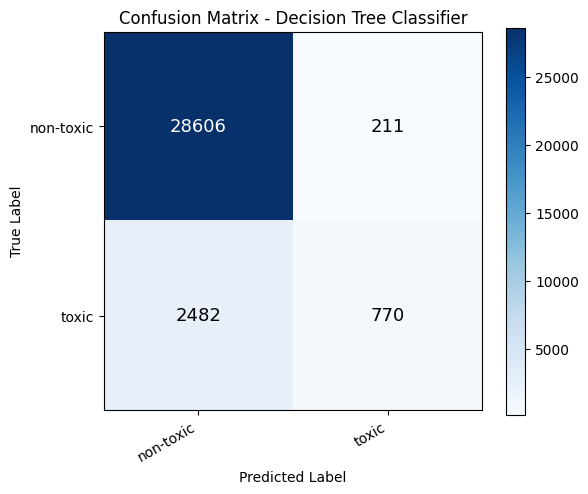

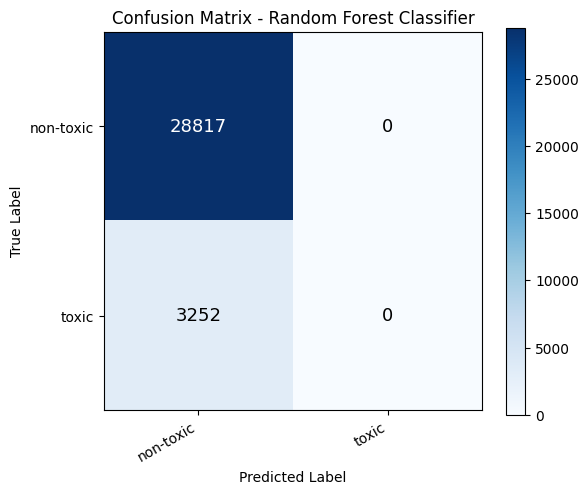

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot confusion matrix from Spark DataFrame predictions.
def plot_confusion_matrix(preds_df, model_name):
    # Convert confusion matrix data to pandas for plotting.
    cm_pdf = (
        preds_df.groupBy("label", "prediction")
        .count()
        .orderBy("label", "prediction")
        .toPandas()
    )
    # Create a 2x2 confusion matrix array.
    cm_array = np.zeros((2, 2), dtype=int)
    for _, row in cm_pdf.iterrows():
        i = int(row["label"])
        j = int(row["prediction"])
        cm_array[i][j] = int(row["count"])
    
    # Plotting the confusion matrix.
    class_names = ["non-toxic", "toxic"]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_array, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(2)); ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix - {model_name}")
    
    # Add text annotations.
    thresh = cm_array.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_array[i, j]), ha="center", va="center",
                    color="white" if cm_array[i, j] > thresh else "black", fontsize=13)
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for two example models.
plot_confusion_matrix(predictions_dict["Decision Tree Classifier"], "Decision Tree Classifier")
plot_confusion_matrix(predictions_dict["Random Forest Classifier"], "Random Forest Classifier")


## 8. Convert Results to a Local Table for Plotting

Small result tables can be converted locally for plotting.
This does **not** violate the Spark requirement because the ML workflow itself remains in Spark.


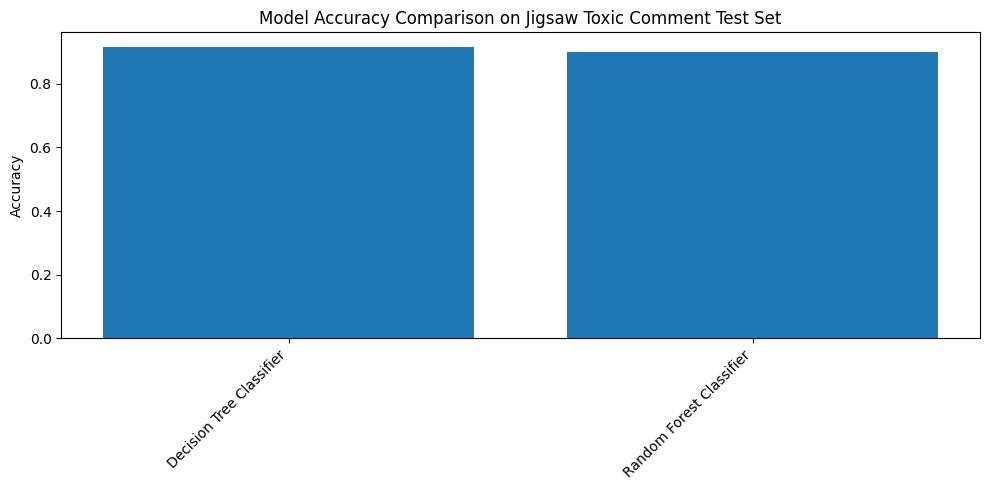

In [12]:
# Simple comparison chart.
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on Jigsaw Toxic Comment Test Set")
plt.tight_layout()
plt.show()


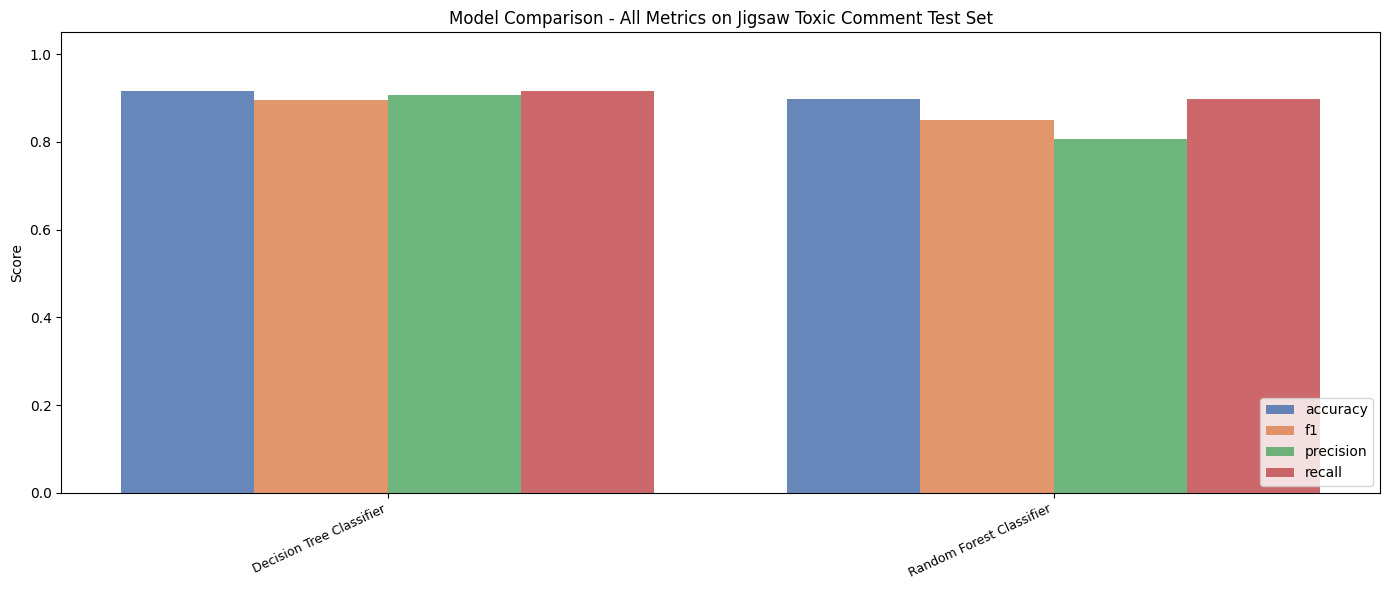

In [13]:
# Grouped bar chart comparing all 4 metrics across all models.
import numpy as np

# Define metrics and colors for the plot.
metrics = ["accuracy", "f1", "precision", "recall"]
model_names = results_df["model"].tolist()
x = np.arange(len(model_names))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
# Create bars for each metric.
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)
# Set x-ticks and labels.
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison - All Metrics on Jigsaw Toxic Comment Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Interpretation Notes for Students

In your notebook and report, explain:
- Which model performed best?
- Whether the results were close or very different
- Why some models may perform better or worse on sparse text features
- How class imbalance affects accuracy, precision, recall, and F1
- Any limitations of converting the original six-label Kaggle task into one binary `any toxic` label

You should not only show numbers; you should also interpret them.


## 10. Required Report Reminder

Your report should summarize:
1. The workflow you used
2. The Spark pipeline components
3. The models you trained
4. The evaluation results
5. Your discussion and conclusions


## 11. Important Reminder About Phase 2

This notebook now uses the Jigsaw toxic comment dataset and can be extended further by training one model per toxicity label or by using Spark NLP-style feature engineering.


## 12. Checklist Before Submission

- [ ] Used Spark DataFrames
- [ ] Used Spark ML Pipeline components
- [ ] Trained at least 6 approved models
- [ ] Reported accuracy, precision, recall, and F1
- [ ] Included confusion matrices for at least 2 models
- [ ] Compared models in a table or figure
- [ ] Wrote clear comments in the notebook
- [ ] Prepared the 3–4 page report
